In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load trained model
model = joblib.load("regression_model.pkl")
print("Model loaded!")

# Load dataset
df = pd.read_csv("clean2.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Define target (correct column name)
target_col = "Anxiety Level (1-10)"
y = df[target_col]

# Prepare features (drop target if it exists)
X = df.drop(columns=[target_col], errors="ignore")

# Predict for the entire dataset
pred_scores = model.predict(X)

# Function to interpret scores
def interpret(score):
    if score < 3:
        cls = "Low"
    elif score < 6:
        cls = "Moderate"
    else:
        cls = "High"
    if score >= 4:
        chance = 50 + ((score - 4) / 6) * 50
    else:
        chance = (score / 4) * 50
    chance = round(min(100, max(0, chance)), 2)
    return cls, chance

# Build results table (stored, not printed)
results_df = pd.DataFrame([{
    "Predicted_Score": round(score, 2),
    "Clinical_Class": interpret(score)[0],
    "Chance_of_Anxiety_%": interpret(score)[1]
} for score in pred_scores])

# Evaluate predictions
mae = mean_absolute_error(y, pred_scores)
mse = mean_squared_error(y, pred_scores)
r2 = r2_score(y, pred_scores)

# Print evaluation metrics
print("\nEvaluation Metrics on Full Dataset:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Model loaded!
Dataset loaded: 11000 rows, 19 columns

Evaluation Metrics on Full Dataset:
MAE: 0.85
MSE: 1.15
R² Score: 0.74


Baseline Metrics (predict mean):
MAE: 1.60, MSE: 4.48, R²: 0.00

Your Model Metrics:
MAE: 0.85, MSE: 1.15, R²: 0.74


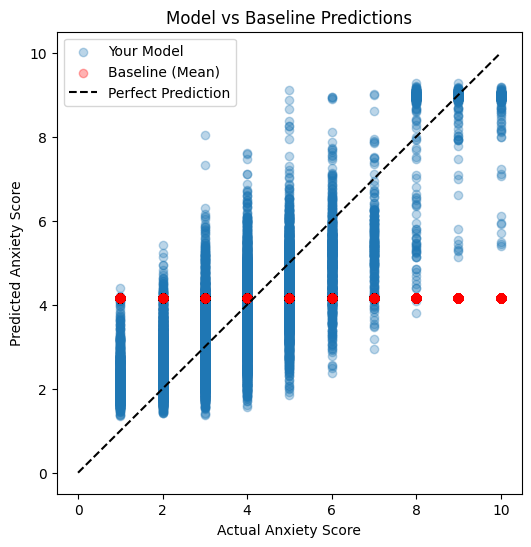

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Your model predictions and true values
y_pred = pred_scores  # from your previous model predictions
y_true = y            # actual anxiety scores

# Baseline: predict mean of the target
mean_pred = np.mean(y_true)
baseline_pred = np.full_like(y_true, mean_pred)

# Evaluate baseline
baseline_mae = mean_absolute_error(y_true, baseline_pred)
baseline_mse = mean_squared_error(y_true, baseline_pred)
baseline_r2 = r2_score(y_true, baseline_pred)

# Evaluate your model
model_mae = mean_absolute_error(y_true, y_pred)
model_mse = mean_squared_error(y_true, y_pred)
model_r2 = r2_score(y_true, y_pred)

# Print comparison
print("Baseline Metrics (predict mean):")
print(f"MAE: {baseline_mae:.2f}, MSE: {baseline_mse:.2f}, R²: {baseline_r2:.2f}\n")

print("Your Model Metrics:")
print(f"MAE: {model_mae:.2f}, MSE: {model_mse:.2f}, R²: {model_r2:.2f}")

# Quick visual comparison
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.3, label='Your Model')
plt.scatter(y_true, baseline_pred, alpha=0.3, label='Baseline (Mean)', color='red')
plt.plot([0, 10], [0, 10], color='black', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Anxiety Score")
plt.ylabel("Predicted Anxiety Score")
plt.title("Model vs Baseline Predictions")
plt.legend()
plt.show()
